In [2]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [3]:
import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain


In [4]:
from bcosgnn.explain import explain
from bcosgnn.evaluation import (
    evaluate_auroc,
    evaluate_jaccard,
 )

## BCos readout

In [5]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out


class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

## BCos GIN conv layer

In [6]:
class BcosGINConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        b=2,
        max_out=1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs,
    ):
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[ 
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index):
        x_original = x
        out = self.propagate(edge_index, x=x, size=None)
        out = (1 + self.eps) * x_original + out
        return self.transform(out)

    def message(self, x_j):
        return x_j

    def message_and_aggregate(self, adj_t, x):
        return matmul(adj_t, x, reduce=self.aggr)

## Bcos GNN


In [7]:
class BCosGNN(torch.nn.Module):
    def __init__(
        self,
        node_size: int,
        hidden_channels: int | list[int],
        conv_layer: type[MessagePassing],
        num_convs: int,
        readout: Readout,
        b: float = 2,
        max_out: int = 1,
        conv_kwargs: dict[str, Any] | None = None,
    ):
        super().__init__()
        if isinstance(hidden_channels, int):
            hidden_channels = [hidden_channels]
        conv_kwargs = conv_kwargs or {}
        self.lin_node = BcosLinear(
            node_size,
            hidden_channels[0],
        )
        self.convs = torch.nn.ModuleList(
            [
                conv_layer(
                    channels=hidden_channels,
                    b=b,
                    max_out=max_out,
                    **conv_kwargs,
                )
                for _ in range(num_convs)
            ]
        )
        self.readout = readout

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        return self.readout(x, batch)

## Dataset Loading (custom Ba2Motifs)

In [8]:
import torch
import os
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


raw_data_path = "/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt"
print(f"Loading data directly from: {raw_data_path}")



dataset_list = torch.load(raw_data_path, weights_only=False)
print(f"Successfully loaded {len(dataset_list)} graphs.")

for i, data in enumerate(dataset_list):
    data.y = torch.tensor([0]) if i < 500 else torch.tensor([1])
    data.x = torch.ones((data.num_nodes, 1))

first_graph = dataset_list[0]
num_features = first_graph.num_features
all_labels = torch.cat([d.y for d in dataset_list])
num_classes = len(all_labels.unique())

print(f'Number of graphs: {len(dataset_list)}')
print(f'Number of features: {num_features}')
print(f'Number of classes: {num_classes}')


train_split_idx, test_split_idx = train_test_split(
    np.arange(len(dataset_list)), test_size=0.2, train_size=0.8, random_state=42
)

train_dataset = [dataset_list[i] for i in train_split_idx]
test_dataset = [dataset_list[i] for i in test_split_idx]

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loading data directly from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Successfully loaded 1000 graphs.
Number of graphs: 1000
Number of features: 1
Number of classes: 2
Training set size: 800
Test set size: 200
Successfully loaded 1000 graphs.
Number of graphs: 1000
Number of features: 1
Number of classes: 2
Training set size: 800
Test set size: 200


In [9]:
def get_one_hot_degree_clamped(data, max_degree=10):
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long)
    deg = deg.clamp(max=max_degree)
    one_hot_deg = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(
        torch.float
    )
    data.x = one_hot_deg.float()
    return data

  Graph Index 0: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 1: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 2: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 3: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 4: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 500: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 501: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 502: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 503: Node Mask = [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
  Graph Index 504: Node Mask = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]


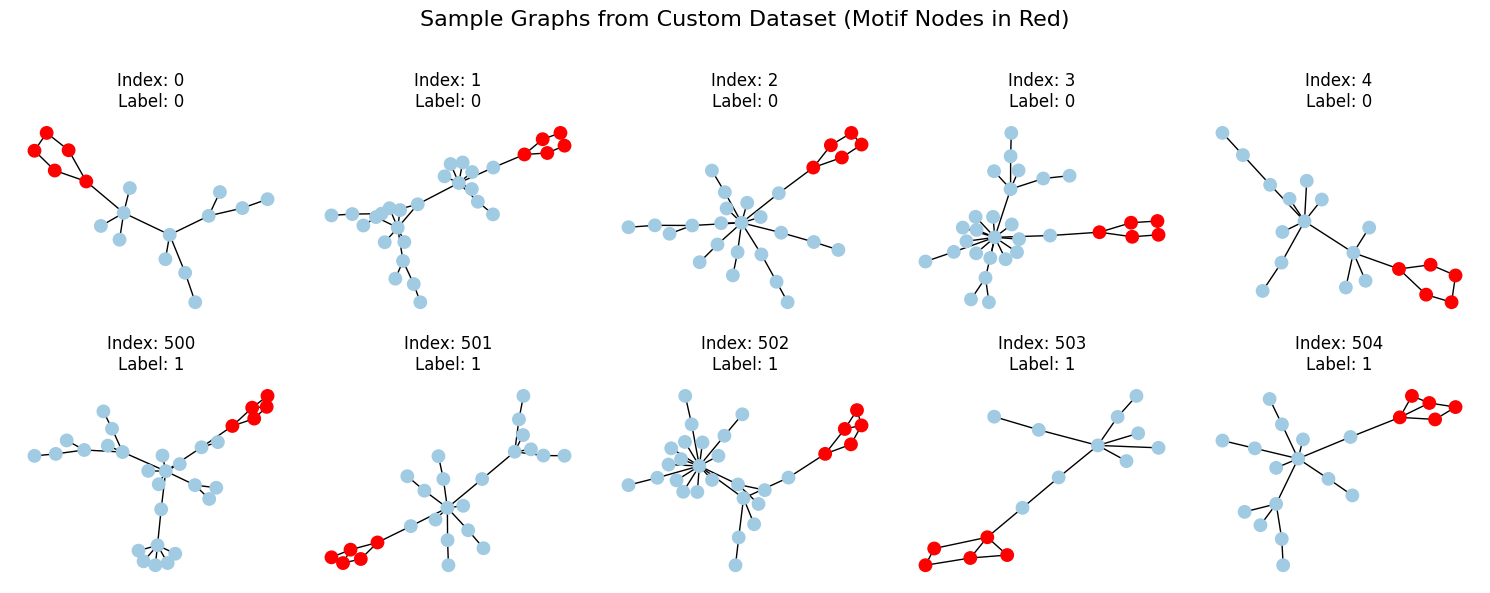

In [10]:
import networkx as nx
import matplotlib.pyplot as plt


class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset_list):
    if data.y.item() == 0 and len(class_0_samples) < 5:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 5:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 5 and len(class_1_samples) == 5:
        break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Graphs from Custom Dataset (Motif Nodes in Red)", fontsize=16)

#  Class 0 (Cycle Motif) 
for i, (original_index, data) in enumerate(class_0_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 0")

#  Class 1 (House Motif) 
for i, (original_index, data) in enumerate(class_1_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Train and test logic

In [11]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: BCosGNN,
    train_data: list,
    test_data: list,
    transform,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
):
    if transform:
        train_data = [transform(d.clone()) for d in train_data]
        test_data = [transform(d.clone()) for d in test_data]

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

In [12]:
def get_many(d, *keys):
    return {d[key] for key in keys}


def to_polars(train_epochs, test_epoch, **markers):
    df_epoch = pl.DataFrame(
        {
            "epoch_index": [epoch["epoch_index"] for epoch in train_epochs] + [0],
            "accuracy": [epoch["accuracy"].item() for epoch in train_epochs]
            + [test_epoch["accuracy"]],
            "split": ["train"] * len(train_epochs) + ["test"],
        }
    )
    if len(markers) > 0:
        df_epoch = df_epoch.with_columns(
            *[
                pl.lit(marker_value).alias(marker_key)
                for marker_key, marker_value in markers.items()
            ]
        )
    return df_epoch, None

In [13]:
train_hyperparams = {
    "num_train_epochs": 200,
    "batch_size": 64,
    "lr": 3e-4,
}

In [14]:
b = 2

best_hyperparams = {
    "node_size": 5,  # Changed from 1 to 5 to match degree features
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGINConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels= [64, 64],
        b=b,
        max_out=1,
    ),
    "b": b,
    "max_out": 1,
}

In [15]:
best_model = BCosGNN(**best_hyperparams)

transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

train_epochs, test_epoch = train_and_test_model(

    model=best_model,

    train_data=train_dataset,

    test_data=test_dataset,

    transform=transform,

    **train_hyperparams,

)

print(f"Best model test accuracy: {test_epoch['accuracy']:.4f}" )

Training BCosGNN: 100%|██████████| 200/200 [00:16<00:00, 11.88it/s]

Best model test accuracy: 1.0000


In [16]:
model = best_model
data = test_dataset[100].clone()

# Apply the degree transform to match training
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
data = transform(data)

node_contributions = explain(
    model,
    data.x,
    data.edge_index,
    torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long),
).detach()

with torch.no_grad():

    pred = model(data.x, data.edge_index, torch.zeros(data.x.size(0), dtype=torch.long))

In [17]:
pred.sum(), node_contributions.sum()

(tensor(32.4116), tensor(32.4116))

In [18]:
import networkx as nx


def visualize_explanation(graph_data, node_importance):
    g = nx.Graph()
    g.add_nodes_from(range(graph_data.num_nodes))
    g.add_edges_from(graph_data.edge_index.t().tolist())

    plt.figure(figsize=(8, 8))

    node_colors = node_importance.numpy()

    edge_colors = [max(node_colors[u], node_colors[v]) for u, v in g.edges()]

    pos = nx.spring_layout(g, seed=42)

    nodes = nx.draw_networkx_nodes(
        g, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=500
    )
    edges = nx.draw_networkx_edges(
        g, pos, edge_color=edge_colors, edge_cmap=plt.cm.viridis, width=2
    )
    nx.draw_networkx_labels(g, pos, font_color="white")

    plt.colorbar(nodes, label="Node Importance (Cosine Similarity)")
    plt.title("Explanation for a single graph")
    plt.show()

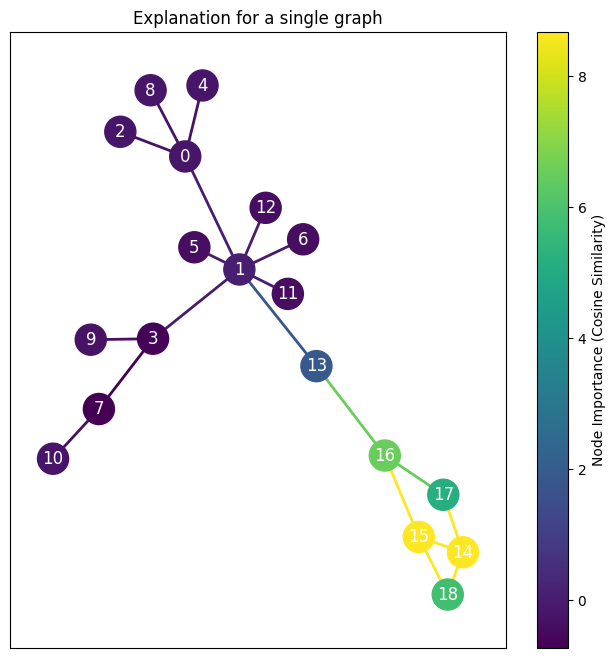

In [19]:
visualize_explanation(data, (node_contributions.sum(1)))


## Quantitative Evaluation of Gradient Explanations

In [20]:
def evaluate_gradient_explanation_accuracy(model, data):

    # Apply degree transform
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    data = transform(data)
    
    # "Cheating" by always explaining for class 0, which aligns with the cycle motif.
    # This is done to get a baseline of what a "perfect" explanation looks like,
    # even if the model itself is not predicting correctly.
    node_contributions = explain(
        model,
        data.x,
        data.edge_index,
        torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long),
    ).detach()
    
    # Take the absolute sum across features to get a single importance score per node
    explanation_scores = node_contributions.abs().sum(1)
    
    # Get the set of ground-truth important nodes
    ground_truth_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].numpy())
    
    # The number of nodes to select is the number of ground-truth nodes
    k = len(ground_truth_nodes)
    
    # If there are no ground-truth nodes, the accuracy is trivially perfect or zero
    if k == 0:
        return 1.0 if len(explanation_scores) == 0 else 0.0

    # Get the indices of the top-k most important nodes according to the model
    _, top_k_indices = torch.topk(explanation_scores, k)
    predicted_important_nodes = set(top_k_indices.numpy())
    
    # Calculate the Jaccard similarity score
    intersection = len(ground_truth_nodes.intersection(predicted_important_nodes))
    union = len(ground_truth_nodes.union(predicted_important_nodes))
    
    return intersection / union if union > 0 else 0.0

# --- Run evaluation over the entire test set ---
gradient_explanation_accuracies = []
for data in tqdm(test_dataset, desc="Evaluating gradient explanations on test set"):
    accuracy = evaluate_gradient_explanation_accuracy(best_model, data.clone())
    gradient_explanation_accuracies.append(accuracy)

average_gradient_accuracy = np.mean(gradient_explanation_accuracies)

print(f"\nAverage Gradient Explanation Accuracy (Jaccard Score) on Test Set: {average_gradient_accuracy:.4f}")
print("\nThis score measures how well the model's top important nodes (from gradients) align with the ground-truth motif nodes.")

Evaluating gradient explanations on test set: 100%|██████████| 200/200 [00:00<00:00, 1300.97it/s]


Average Gradient Explanation Accuracy (Jaccard Score) on Test Set: 0.8717

This score measures how well the model's top important nodes (from gradients) align with the ground-truth motif nodes.


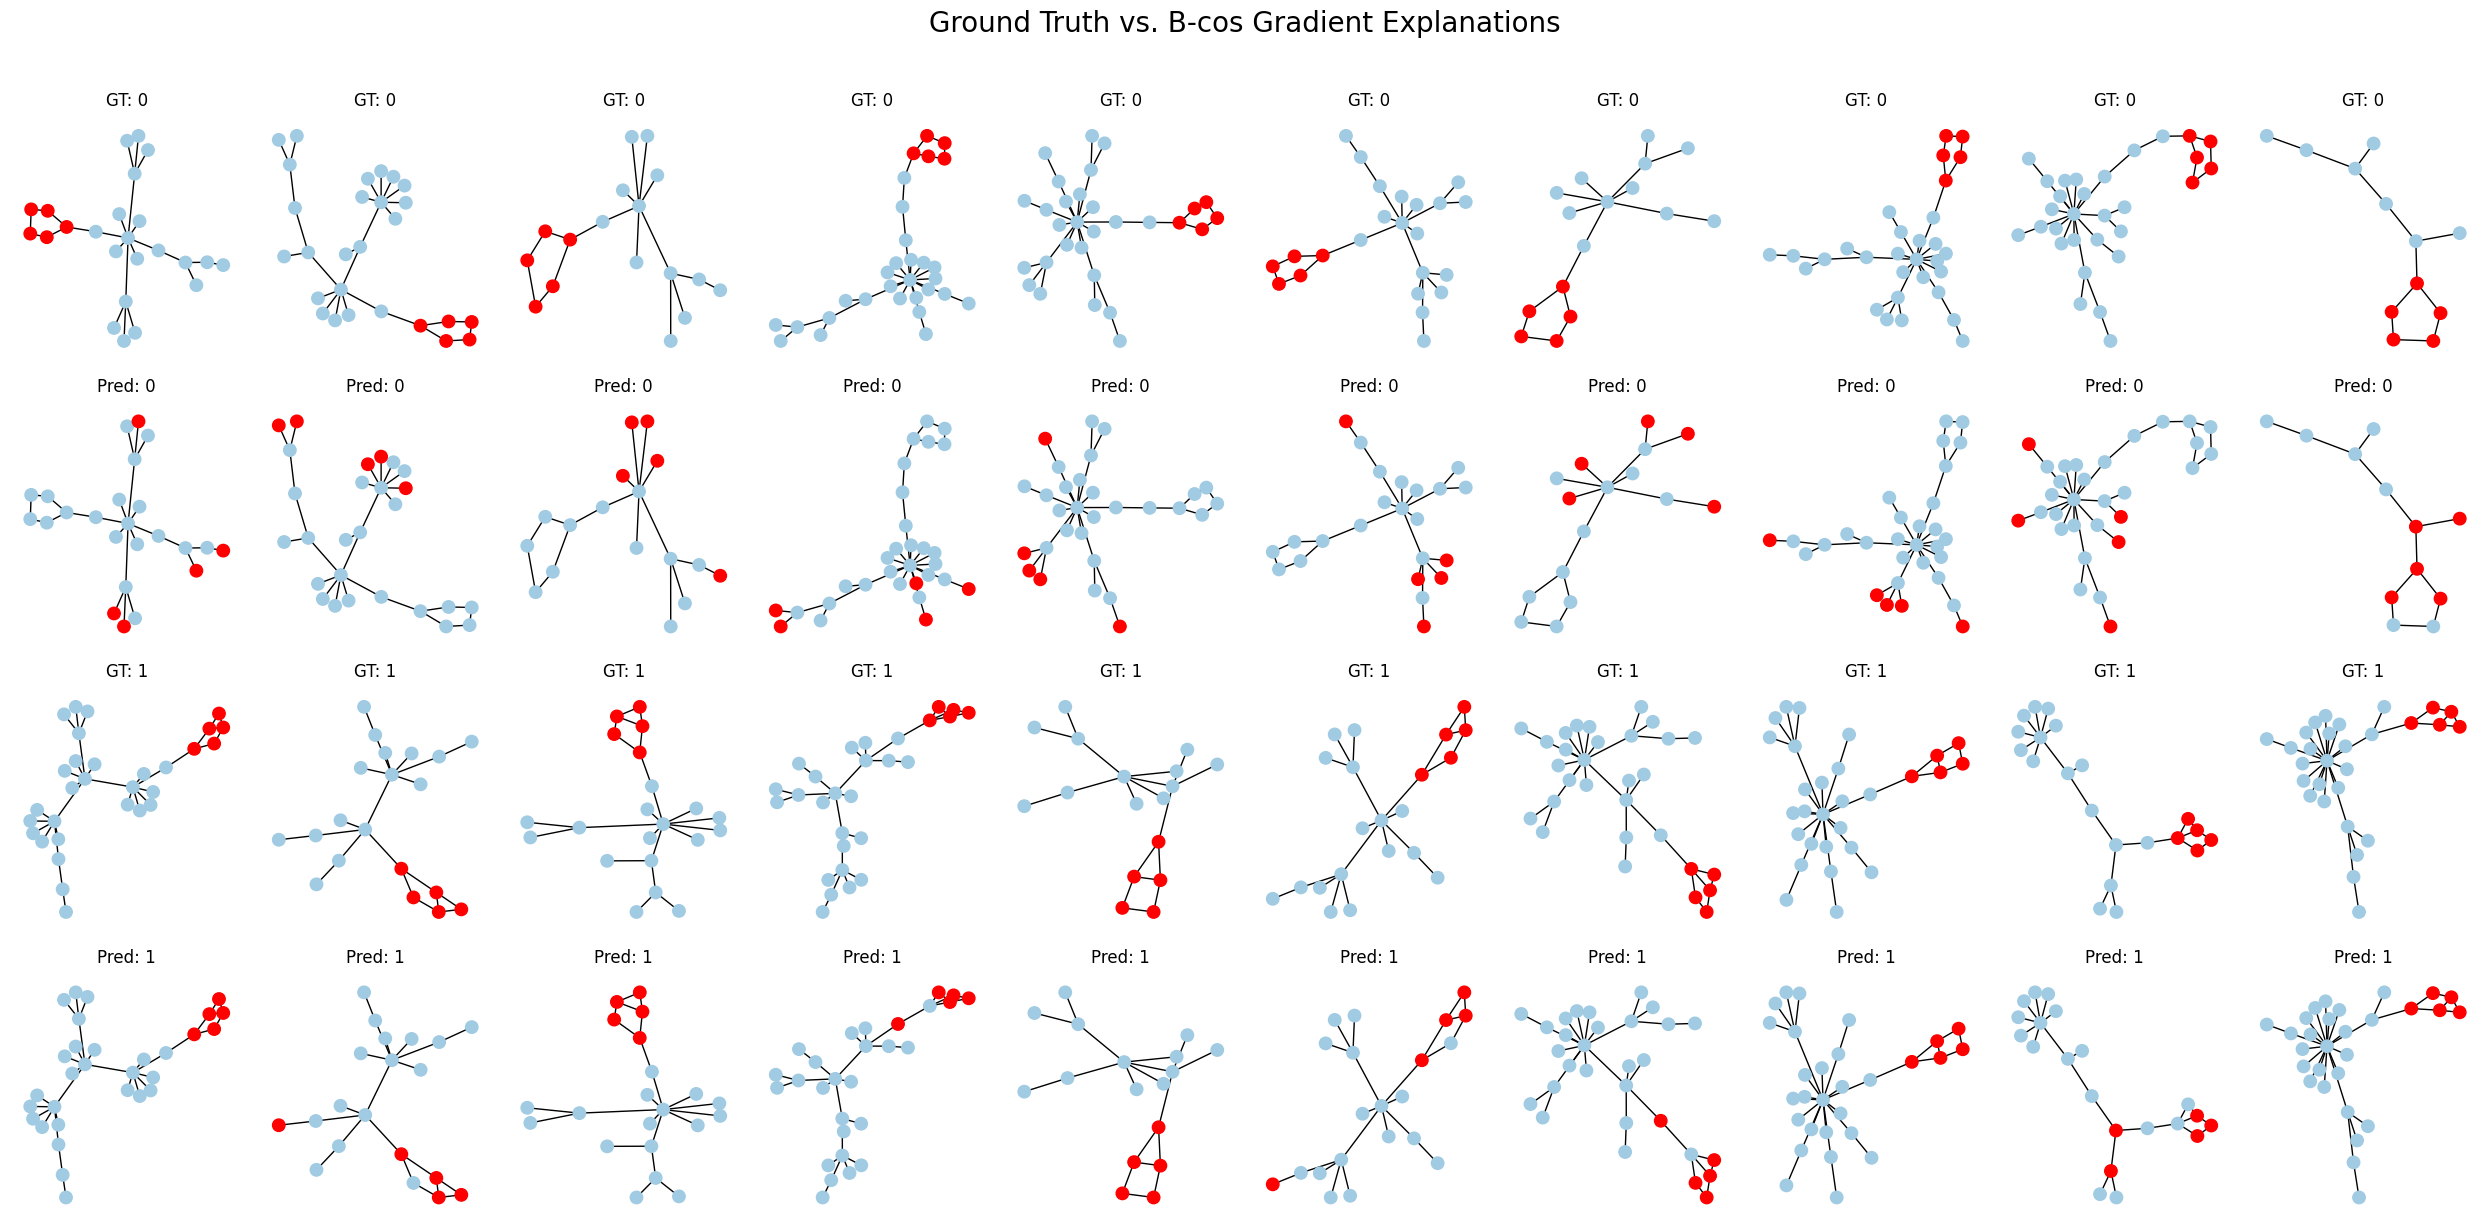

In [21]:
num_samples_per_class = 10

class_0_test_samples = [d for d in test_dataset if d.y.item() == 0][:num_samples_per_class]
class_1_test_samples = [d for d in test_dataset if d.y.item() == 1][:num_samples_per_class]

def get_predicted_mask(model, data, class_to_explain):
    # Apply degree transform
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    data = transform(data)
    
    # Create a batch tensor for single graph
    batch = torch.zeros(data.x.size(0), dtype=torch.long)
    
    # Manually compute gradient-based explanation for single graph
    x = data.x.clone().requires_grad_()
    model.eval()
    
    with torch.enable_grad():
        out = model(x, data.edge_index, batch)
        # For single graph, out is a scalar tensor
        out.backward()
    
    # Get the gradients as node contributions
    node_contributions = x.grad.detach()
    
    explanation_scores = node_contributions.sum(1)
    
    k = int(data.node_mask.sum())
    if k == 0:
        predicted_mask = torch.zeros_like(data.node_mask)
        with torch.no_grad():
            pred_logit = model(data.x, data.edge_index, batch)
        predicted_class = (pred_logit > 0).int().flatten()[0].item()
        return predicted_mask, predicted_class

    _, top_k_indices = torch.topk(explanation_scores, k, largest=True)
    
    predicted_mask = torch.zeros_like(data.node_mask)
    predicted_mask[top_k_indices] = 1
    
    # Get the model's actual prediction for display purposes
    with torch.no_grad():
        pred_logit = model(data.x, data.edge_index, batch)
    predicted_class = (pred_logit > 0).int().flatten()[0].item()
    
    return predicted_mask, predicted_class


fig, axes = plt.subplots(4, num_samples_per_class, figsize=(25, 12))
fig.suptitle("Ground Truth vs. B-cos Gradient Explanations", fontsize=20, y=1.02)


for i, data in enumerate(class_0_test_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    pos = nx.spring_layout(g, seed=42)
    
    # 1. Ground Truth (Class 0)
    ax_gt = axes[0, i]
    gt_mask = data.node_mask.numpy().ravel()
    gt_colors = ['red' if mask == 1 else '#A0CBE2' for mask in gt_mask]
    nx.draw(g, pos, ax=ax_gt, with_labels=False, node_color=gt_colors, node_size=80)
    ax_gt.set_title(f"GT: {data.y.item()}")
    
    # 2. Explanation for Class 0
    ax_pred = axes[1, i]
    pred_mask, predicted_class = get_predicted_mask(best_model, data.clone(), class_to_explain=0)
    pred_mask = pred_mask.numpy().ravel()
    pred_colors = ['red' if mask == 1 else '#A0CBE2' for mask in pred_mask]
    nx.draw(g, pos, ax=ax_pred, with_labels=False, node_color=pred_colors, node_size=80)
    ax_pred.set_title(f"Pred: {predicted_class}")

for i, data in enumerate(class_1_test_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    pos = nx.spring_layout(g, seed=42)
    
    # 3. Ground Truth (Class 1)
    ax_gt = axes[2, i]
    gt_mask = data.node_mask.numpy().ravel()
    gt_colors = ['red' if mask == 1 else '#A0CBE2' for mask in gt_mask]
    nx.draw(g, pos, ax=ax_gt, with_labels=False, node_color=gt_colors, node_size=80)
    ax_gt.set_title(f"GT: {data.y.item()}")
    
    # 4. Explanation for Class 1
    ax_pred = axes[3, i]
    pred_mask, predicted_class = get_predicted_mask(best_model, data.clone(), class_to_explain=1)
    pred_mask = pred_mask.numpy().ravel()
    pred_colors = ['red' if mask == 1 else '#A0CBE2' for mask in pred_mask]
    nx.draw(g, pos, ax=ax_pred, with_labels=False, node_color=pred_colors, node_size=80)
    ax_pred.set_title(f"Pred: {predicted_class}")

plt.tight_layout()
plt.show()

In [22]:

sample_data = test_dataset[50].clone()
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
sample_data_transformed = transform(sample_data)
batch = torch.zeros(sample_data_transformed.x.size(0), dtype=torch.long)

print(f"\n--- EXAMPLE GRAPH (index 50) ---")
print(f"Test graph has {sample_data_transformed.num_nodes} nodes")
print(f"Ground truth motif nodes: {torch.where(sample_data_transformed.node_mask.squeeze() == 1)[0].tolist()}")

# Get model prediction first to determine direction
with torch.no_grad():
    pred_logit = best_model(sample_data_transformed.x, sample_data_transformed.edge_index, batch)
pred_class = 1 if pred_logit.item() > 0 else 0
print(f"Model Prediction: Class {pred_class} (Logit: {pred_logit.item():.4f})")

#  METHOD 1: Using explain() function
print("\n" + "-"*80)
print("METHOD 1: Using explain() function")
print("-"*80)

try:
    node_contributions_buggy = explain(
        best_model,
        sample_data_transformed.x,
        sample_data_transformed.edge_index,
        batch,
    ).detach()
    
    # Apply sign flip if Class 0
    explanation_scores_buggy = node_contributions_buggy.sum(1)
    if pred_class == 0:
        explanation_scores_buggy = -explanation_scores_buggy
        
    k = int(sample_data_transformed.node_mask.sum())
    _, top_k_buggy = torch.topk(explanation_scores_buggy, k)
    
    print(f"Top-{k} predicted important nodes: {top_k_buggy.tolist()}")
    
    # Calculate Jaccard score
    gt_nodes = set(torch.where(sample_data_transformed.node_mask.squeeze() == 1)[0].numpy())
    pred_nodes_buggy = set(top_k_buggy.numpy())
    jaccard_buggy = len(gt_nodes.intersection(pred_nodes_buggy)) / len(gt_nodes.union(pred_nodes_buggy))
    print(f"Jaccard Score (explain() function): {jaccard_buggy:.4f}")
    
except Exception as e:
    print(f"ERROR: {type(e).__name__}: {e}")
    gt_nodes = set(torch.where(sample_data_transformed.node_mask.squeeze() == 1)[0].numpy())
    pred_nodes_buggy = set()
    jaccard_buggy = 0.0



#  EVALUATE ON ENTIRE TEST SET 
print("\n" + "="*80)
print("FULL TEST SET EVALUATION (200 graphs)")
print("="*80)

avg_jaccard_buggy = evaluate_jaccard(best_model, test_dataset, method='explain', transform=transform)

print(f"Average Jaccard Score (Explain.py):       {avg_jaccard_buggy:.4f}")

print("SUMMARY")
print(f" Full Test Set (200 graphs)")
print(f"Average Jaccard Score:")
print(f"  Explain.py:       {avg_jaccard_buggy:.4f}")



--- EXAMPLE GRAPH (index 50) ---
Test graph has 28 nodes
Ground truth motif nodes: [23, 24, 25, 26, 27]
Model Prediction: Class 1 (Logit: 19.8790)

--------------------------------------------------------------------------------
METHOD 1: Using explain() function
--------------------------------------------------------------------------------
Top-5 predicted important nodes: [24, 23, 27, 25, 26]
Jaccard Score (explain() function): 1.0000

FULL TEST SET EVALUATION (200 graphs)


Evaluating Jaccard (explain): 100%|██████████| 200/200 [00:00<00:00, 927.37it/s]

Average Jaccard Score (Explain.py):       0.8717
SUMMARY
 Full Test Set (200 graphs)
Average Jaccard Score:
  Explain.py:       0.8717


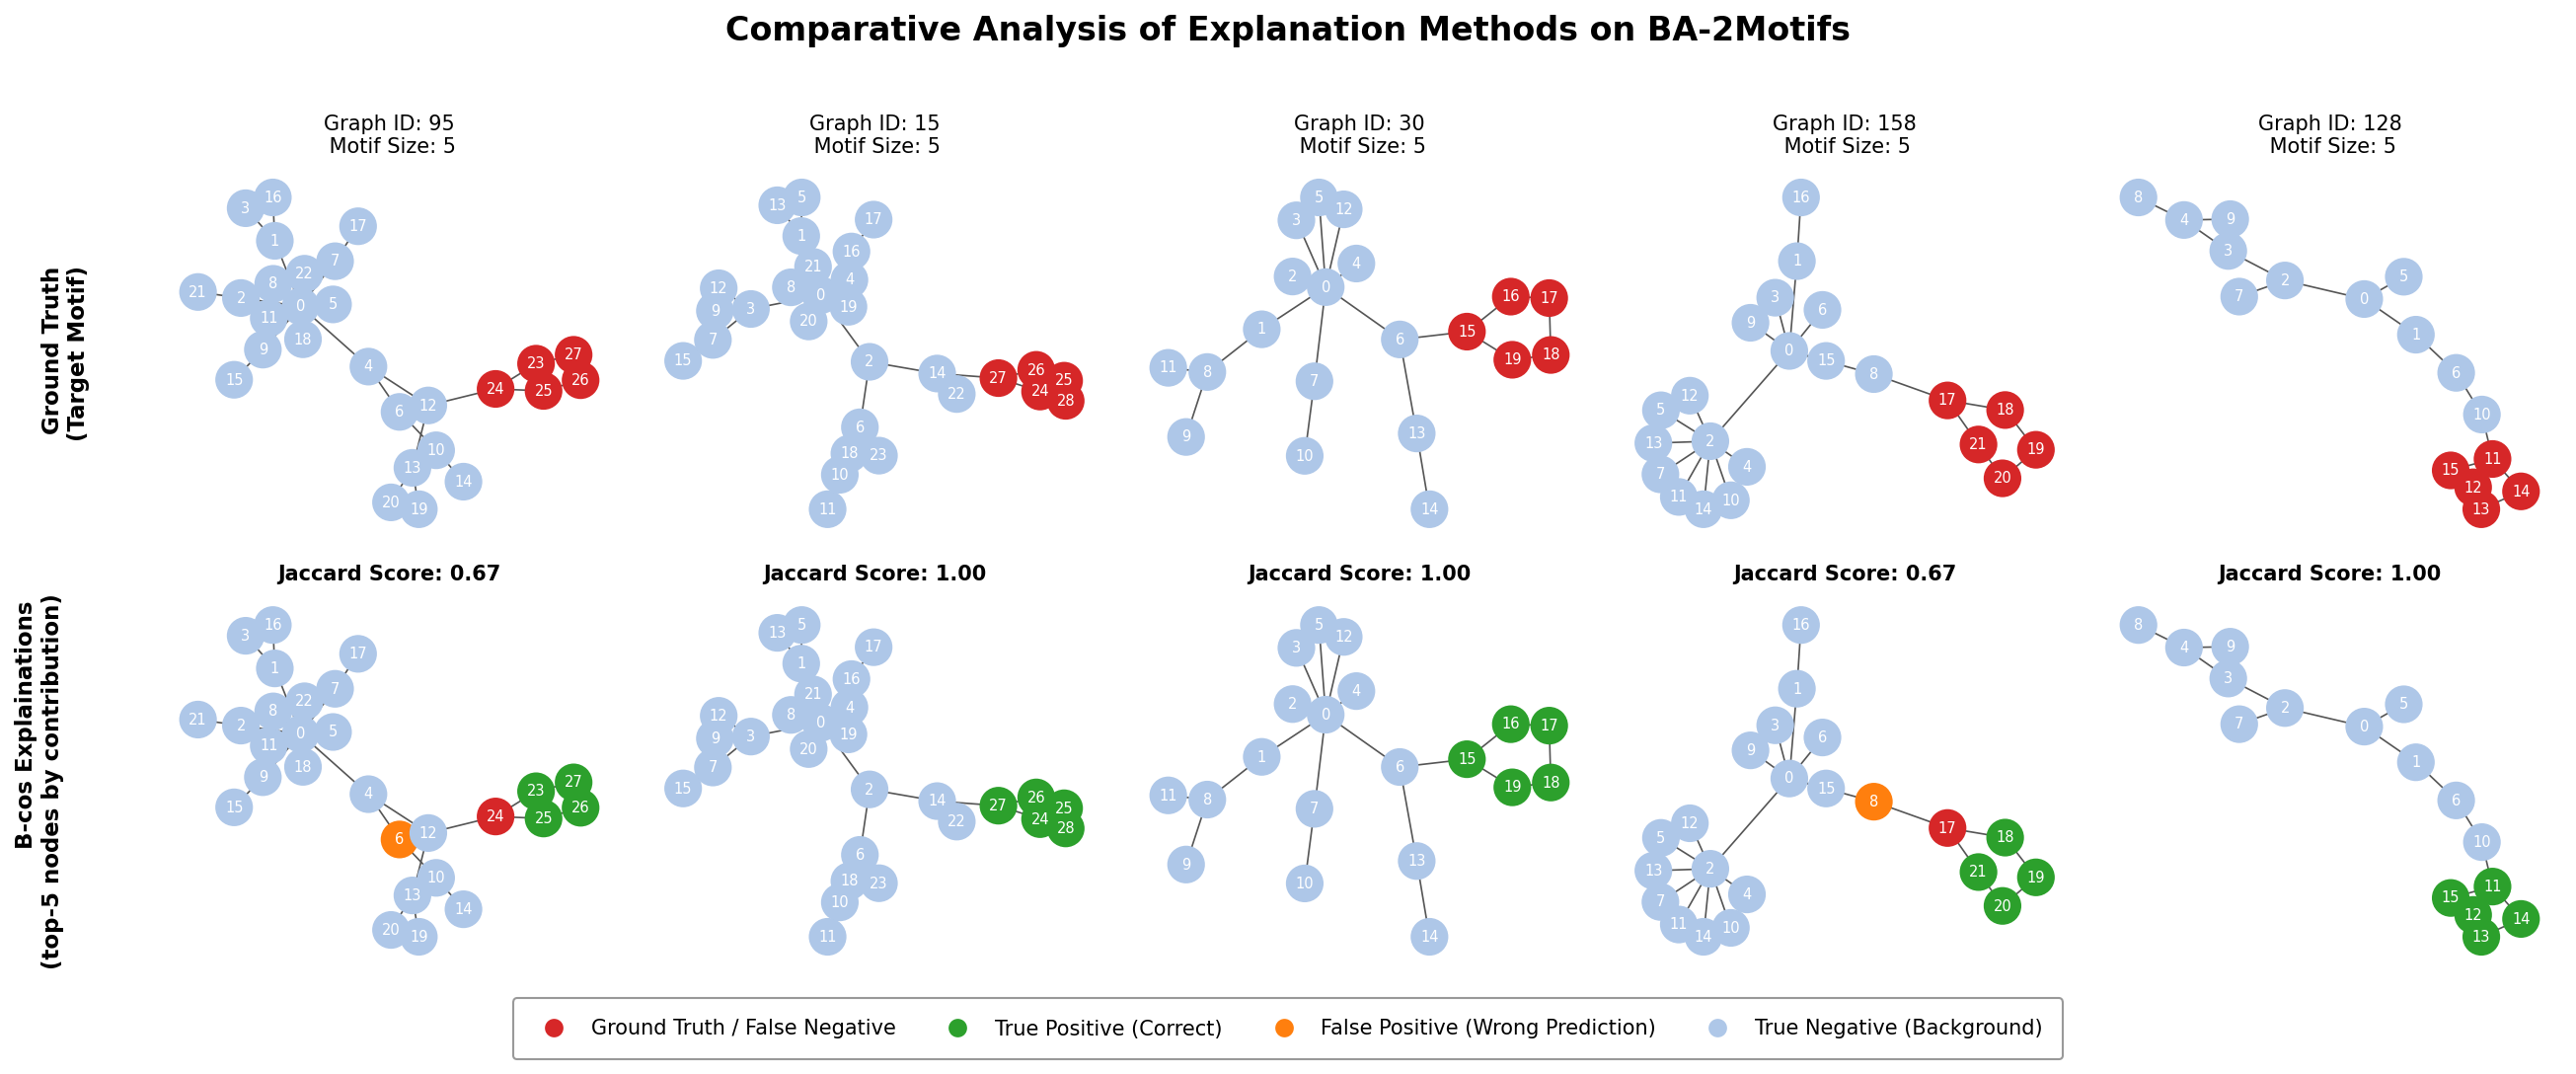

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import functools

def get_node_colors(num_nodes, gt_nodes, pred_nodes):
    colors = []
    for node_id in range(num_nodes):
        if node_id in pred_nodes and node_id in gt_nodes:
            colors.append('#2ca02c')  # Green (True Positive)
        elif node_id in pred_nodes:
            colors.append('#ff7f0e')  # Orange (False Positive)
        elif node_id in gt_nodes:
            colors.append('#d62728')  # Red (False Negative / Missed)
        else:
            colors.append('#aec7e8')  # Light Blue (True Negative)
    return colors

def visualize_comparative_explanations(model, dataset, num_samples=20, seed=42):

    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.family'] = 'sans-serif'
    
    np.random.seed(seed)
    sample_indices = np.random.choice(len(dataset), num_samples, replace=False)
    sample_graphs = [dataset[i] for i in sample_indices]
    
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    
    # CHANGED: 4 rows -> 2 rows
    fig, axes = plt.subplots(2, num_samples, figsize=(3.5 * num_samples, 7.5)) # Adjusted height for 2 rows
    
    # Add row labels
    row_labels = [
        "Ground Truth\n(Target Motif)", 
        "B-cos Explainations \n(top-5 nodes by contribution)\n",
    ]
    
    # Loop over the 2 rows to set labels
    for ax, label in zip(axes[:, 0], row_labels):
        ax.annotate(label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 25, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size=11, ha='right', va='center', rotation=90, fontweight='bold')

    for col_idx, (graph_idx, data) in enumerate(zip(sample_indices, sample_graphs)):
        # Prepare data
        data_transformed = transform(data.clone())
        batch = torch.zeros(data_transformed.x.size(0), dtype=torch.long)
        
        # Graph layout (computed once per column to keep positions consistent)
        g = nx.Graph()
        g.add_nodes_from(range(data.num_nodes))
        g.add_edges_from(data.edge_index.t().tolist())
        pos = nx.spring_layout(g, seed=42) 
        
        # Ground Truth Info
        gt_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].numpy())
        k = len(gt_nodes)
        
        # Row 1: Ground Truth 
        ax_gt = axes[0, col_idx]
        # Red for motif, Blue for background
        gt_colors = ['#d62728' if i in gt_nodes else '#aec7e8' for i in range(data.num_nodes)]
        
        nx.draw(g, pos, ax=ax_gt, with_labels=True, node_color=gt_colors, 
                node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
        ax_gt.set_title(f"Graph ID: {graph_idx}\n Motif Size: {k}", fontsize=10)
        
        # Get prediction to determine sign
        x_manual = data_transformed.x.clone().requires_grad_()
        model.eval()
        with torch.enable_grad():
            out = model(x_manual, data_transformed.edge_index, batch)
        pred_class = 1 if out.item() > 0 else 0
        
        # Row 2: explain() Function 
        ax_explain = axes[1, col_idx]
        try:
            node_contrib = explain(model, data_transformed.x, data_transformed.edge_index, batch).detach()
            scores = node_contrib.sum(1)
            if pred_class == 0:
                scores = -scores
                
            _, top_k = torch.topk(scores, k)
            pred_nodes = set(top_k.numpy())
            
            jaccard = len(gt_nodes.intersection(pred_nodes)) / len(gt_nodes.union(pred_nodes)) if len(gt_nodes.union(pred_nodes)) > 0 else 0.0
            colors = get_node_colors(data.num_nodes, gt_nodes, pred_nodes)
            
            nx.draw(g, pos, ax=ax_explain, with_labels=True, node_color=colors, 
                    node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
            ax_explain.set_title(f"Jaccard Score: {jaccard:.2f}", fontsize=10, fontweight='bold')
        except Exception:
            ax_explain.text(0.5, 0.5, "Computation Failed", ha='center', va='center', color='red')
            ax_explain.set_axis_off()

    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Ground Truth / False Negative'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=10, label='True Positive (Correct)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=10, label='False Positive (Wrong Prediction)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#aec7e8', markersize=10, label='True Negative (Background)'),
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.01), 
               frameon=True, fontsize=10, borderpad=1, edgecolor='gray')
    
    plt.suptitle("Comparative Analysis of Explanation Methods on BA-2Motifs", fontsize=16, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.show()

# Run
visualize_comparative_explanations(best_model, test_dataset, num_samples=5)

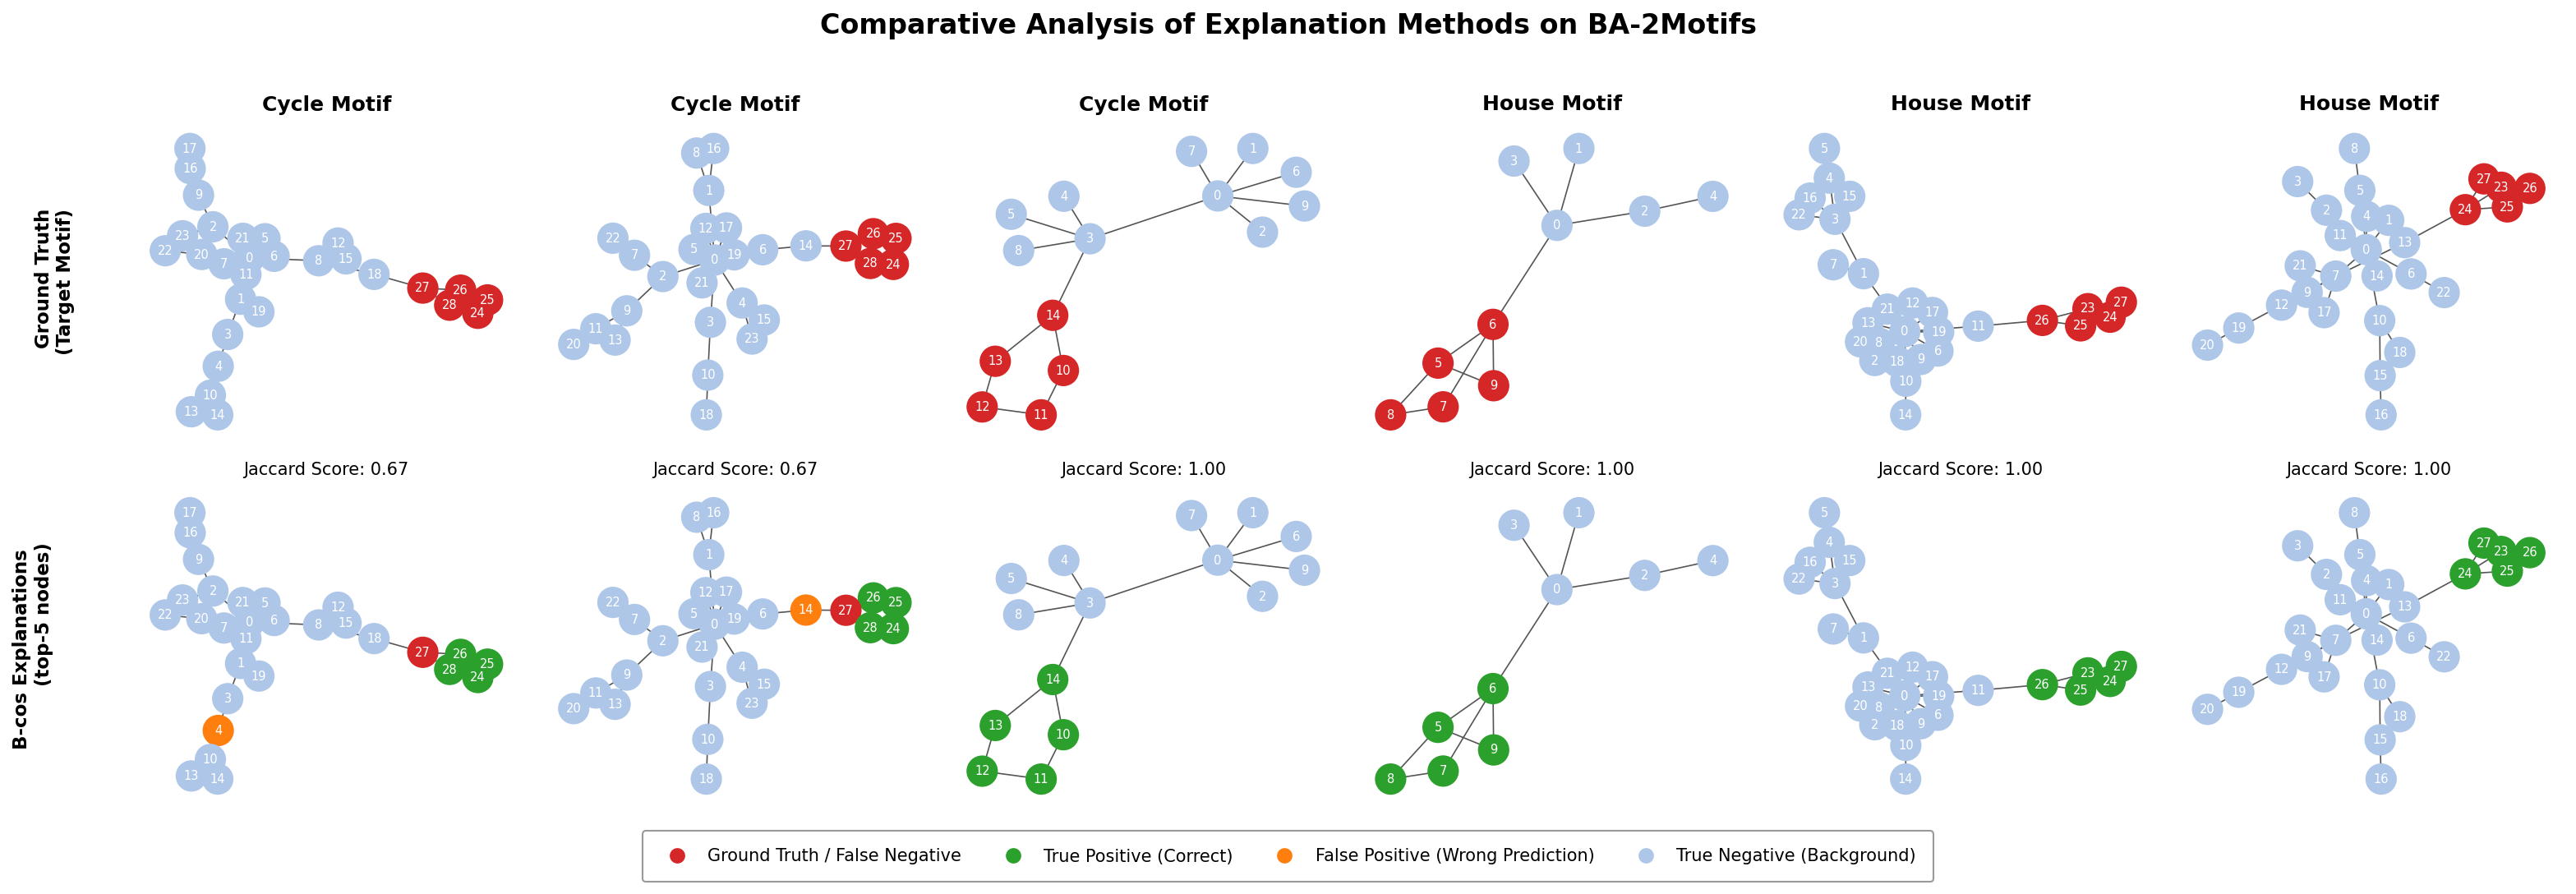

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import functools

def get_node_colors(num_nodes, gt_nodes, pred_nodes):
    colors = []
    for node_id in range(num_nodes):
        if node_id in pred_nodes and node_id in gt_nodes:
            colors.append('#2ca02c')  # Green (True Positive)
        elif node_id in pred_nodes:
            colors.append('#ff7f0e')  # Orange (False Positive)
        elif node_id in gt_nodes:
            colors.append('#d62728')  # Red (False Negative / Missed)
        else:
            colors.append('#aec7e8')  # Light Blue (True Negative)
    return colors

def visualize_comparative_explanations(model, dataset, seed=42):
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.family'] = 'sans-serif'
    
    # 1. Pick 3 random graphs from Label 0 and 3 from Label 1
    np.random.seed(seed)
    
    # Get indices for each class
    indices_0 = [i for i, data in enumerate(dataset) if data.y.item() == 0]
    indices_1 = [i for i, data in enumerate(dataset) if data.y.item() == 1]
    
    # Sample 3 from each
    if len(indices_0) < 3 or len(indices_1) < 3:
        raise ValueError("Dataset does not contain enough samples for each class (need 3 each).")
        
    sample_indices_0 = np.random.choice(indices_0, 3, replace=False)
    sample_indices_1 = np.random.choice(indices_1, 3, replace=False)
    
    sample_indices = np.concatenate([sample_indices_0, sample_indices_1])
    sample_graphs = [dataset[i] for i in sample_indices]
    
    num_samples = 6  # Fixed at 3 + 3
    
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    
    # 2 rows, 6 columns
    fig, axes = plt.subplots(2, num_samples, figsize=(3.5 * num_samples, 7.5)) 
    
    row_labels = [
        "Ground Truth\n(Target Motif)", 
        "B-cos Explanations \n(top-5 nodes)\n",
    ]
    
    # Loop over the 2 rows to set labels
    for ax, label in zip(axes[:, 0], row_labels):
        ax.annotate(label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 25, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size=11, ha='right', va='center', rotation=90, fontweight='bold')

    for col_idx, (graph_idx, data) in enumerate(zip(sample_indices, sample_graphs)):
        # Prepare data
        data_transformed = transform(data.clone())
        batch = torch.zeros(data_transformed.x.size(0), dtype=torch.long)
        
        # Graph layout
        g = nx.Graph()
        g.add_nodes_from(range(data.num_nodes))
        g.add_edges_from(data.edge_index.t().tolist())
        pos = nx.spring_layout(g, seed=42) 
        
        # Ground Truth Info
        gt_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].numpy())
        k = len(gt_nodes)
        
        # Row 1: Ground Truth 
        ax_gt = axes[0, col_idx]
        gt_colors = ['#d62728' if i in gt_nodes else '#aec7e8' for i in range(data.num_nodes)]
        
        # RESTORED: with_labels=True
        nx.draw(g, pos, ax=ax_gt, with_labels=True, node_color=gt_colors, 
                node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
        
        # UPDATED: Specific Motif Titles
        label_name = "Cycle Motif" if data.y.item() == 0 else "House Motif"
        ax_gt.set_title(label_name, fontsize=12, fontweight='bold')
        
        # Get prediction
        x_manual = data_transformed.x.clone().requires_grad_()
        model.eval()
        with torch.enable_grad():
            out = model(x_manual, data_transformed.edge_index, batch)
        pred_class = 1 if out.item() > 0 else 0
        
        # Row 2: explain() Function 
        ax_explain = axes[1, col_idx]
        try:
            node_contrib = explain(model, data_transformed.x, data_transformed.edge_index, batch).detach()
            scores = node_contrib.sum(1)
            if pred_class == 0:
                scores = -scores
                
            _, top_k = torch.topk(scores, k)
            pred_nodes = set(top_k.numpy())
            
            jaccard = len(gt_nodes.intersection(pred_nodes)) / len(gt_nodes.union(pred_nodes)) if len(gt_nodes.union(pred_nodes)) > 0 else 0.0
            colors = get_node_colors(data.num_nodes, gt_nodes, pred_nodes)
            
            # RESTORED: with_labels=True
            nx.draw(g, pos, ax=ax_explain, with_labels=True, node_color=colors, 
                    node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
            ax_explain.set_title(f"Jaccard Score: {jaccard:.2f}", fontsize=10)
        except Exception:
            ax_explain.text(0.5, 0.5, "Computation Failed", ha='center', va='center', color='red')
            ax_explain.set_axis_off()

    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Ground Truth / False Negative'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=10, label='True Positive (Correct)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=10, label='False Positive (Wrong Prediction)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#aec7e8', markersize=10, label='True Negative (Background)'),
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.01), 
               frameon=True, fontsize=10, borderpad=1, edgecolor='gray')
    
    plt.suptitle("Comparative Analysis of Explanation Methods on BA-2Motifs", fontsize=16, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    
    plt.savefig("comparative_explanations.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# Run
visualize_comparative_explanations(best_model, test_dataset)

In [24]:
# Run evaluation
print("\n" + "="*80)
print("RETRIEVAL AUROC EVALUATION")
print("="*80)

transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)


# 3. Explain (Method A)
avg_auroc_buggy = evaluate_auroc(best_model, test_dataset, method='explain', transform=transform)
print(f"Average Retrieval AUROC (Method A: explain/):     {avg_auroc_buggy:.4f}")


RETRIEVAL AUROC EVALUATION


Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 476.08it/s]

Average Retrieval AUROC (Method A: explain/):     0.9887


## ICML-style reporting: multi-seed 5-fold CV (train+val only) + held-out test evaluation
- We keep a fixed held-out **test set** for inference/explanations only.
- We run **5-fold stratified CV** on the remaining train+val split.
- For each (seed, fold) run we train a fresh model, then report **test** metrics: classification accuracy, explanation Jaccard, explanation AUROC (all from `explain.py`).

In [26]:
import torch
import random
from dataclasses import dataclass
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split

# NOTE: `bcosgnn/evaluation.py` uses `.numpy()` on `node_mask`, so keep evaluation on CPU unless you patch it to `.cpu().numpy()`.
DEVICE = torch.device("cpu")

@dataclass(frozen=True)
class CVConfig:
    dataset_name: str = "Custom_BA2Motif"
    test_size: float = 0.2
    test_split_seed: int = 42            # fixed held-out test split
    seeds: tuple[int, ...] = (0, 1, 2, 3, 4)
    n_splits: int = 5
    num_train_epochs: int = 200
    batch_size: int = 64
    lr: float = 3e-4
    final_model_seed: int = 0            # used for the single final-model export
    export_dir: str = "outputs/explanations"

cfg = CVConfig()
cfg

CVConfig(dataset_name='Custom_BA2Motif', test_size=0.2, test_split_seed=42, seeds=(0, 1, 2, 3, 4), n_splits=5, num_train_epochs=200, batch_size=64, lr=0.0003, final_model_seed=0, export_dir='outputs/explanations')

In [27]:
b = 2

best_hyperparams = {
    "node_size": 5,  # Changed from 1 to 5 to match degree features
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGINConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels= [64, 64],
        b=b,
        max_out=1,
    ),
    "b": b,
    "max_out": 1,
}

In [28]:
from sklearn.metrics import f1_score
def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

@torch.inference_mode()
def evaluate_accuracy_f1(model: torch.nn.Module, dataset: list[Data], transform=None, batch_size: int = 256):
    model.eval()
    loader = DataLoader(
        [transform(d.clone()) if transform else d.clone() for d in dataset],
        batch_size=batch_size,
        shuffle=False,
    )

    all_pred = []
    all_labels = []
    correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch).flatten()
        pred = (logits > 0).long()
        y = batch.y.long().flatten()
        correct += int((pred == y).sum().item())
        total += int(y.numel())
        all_pred.append(pred.cpu())
        all_labels.append(y.cpu())
    
    all_pred = torch.cat(all_pred).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = (all_pred == all_labels).mean()

    f1 = f1_score(all_labels, all_pred , average='binary')

    return acc, f1



def _default_test_indices_path(cfg: CVConfig) -> Path:
    export_dir = Path(cfg.export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)
    return export_dir / f"{cfg.dataset_name}__testseed{cfg.test_split_seed}__test_indices.npy"

def make_fixed_test_split(
    dataset_list: list[Data],
    *,
    test_size: float,
    seed: int,
    indices_path: Path | None = None,
 ):
    idx = np.arange(len(dataset_list))
    if indices_path is not None and indices_path.exists():
        test_idx = np.load(indices_path).astype(int)
        mask = np.ones(len(dataset_list), dtype=bool)
        mask[test_idx] = False
        trainval_idx = idx[mask]
        return trainval_idx, test_idx

    y = np.array([int(d.y.item()) for d in dataset_list])
    trainval_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )
    if indices_path is not None:
        np.save(indices_path, np.asarray(test_idx, dtype=int))
    return trainval_idx, test_idx

def train_model_on_split(train_data: list[Data], *, seed: int, cfg: CVConfig):
    set_global_seed(seed)
    model = BCosGNN(**best_hyperparams).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = BCEWithLogitsLoss()
    loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True)
    model.train()
    for _ in range(cfg.num_train_epochs):
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.batch).flatten()
            loss = criterion(logits, batch.y.float().flatten())
            optim.zero_grad()
            loss.backward()
            optim.step()
    return model

def run_multiseed_cv_test_eval(dataset_list: list[Data], transform, cfg: CVConfig):
    # Fixed held-out test split (persisted)
    indices_path = _default_test_indices_path(cfg)
    trainval_idx, test_idx = make_fixed_test_split(
        dataset_list, test_size=cfg.test_size, seed=cfg.test_split_seed, indices_path=indices_path
    )
    y_all = np.array([int(d.y.item()) for d in dataset_list])
    y_trainval = y_all[trainval_idx]
    test_dataset = [dataset_list[i] for i in test_idx]

    results = []
    for seed in cfg.seeds:
        set_global_seed(seed)
        skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=seed)
        for fold, (tr_rel, _val_rel) in enumerate(skf.split(trainval_idx, y_trainval), start=1):
            tr_idx = trainval_idx[tr_rel]
            train_dataset = [dataset_list[i] for i in tr_idx]
            model = train_model_on_split(
                [transform(d.clone()) if transform else d.clone() for d in train_dataset],
                seed=seed,
                cfg=cfg,
            )
            acc = evaluate_accuracy_f1(model, test_dataset, transform=transform)[0]
            f1_score = evaluate_accuracy_f1(model, test_dataset, transform=transform)[1]
            jacc = evaluate_jaccard(model, test_dataset, method="explain", transform=transform)
            auroc = evaluate_auroc(model, test_dataset, method="explain", transform=transform)
            results.append(
                {
                    "seed": seed,
                    "fold": fold,
                    "test_accuracy": float(acc),
                    "test_f1_score": float(f1_score),
                    "test_jaccard_explain": float(jacc),
                    "test_auroc_explain": float(auroc),
                }
            )
    return pl.DataFrame(results)

In [43]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import random
from pathlib import Path
from torch_geometric.loader import DataLoader
from torch.nn import BCEWithLogitsLoss
import polars as pl

# Assuming Data, CVConfig, BCosGNN, DEVICE, evaluate_jaccard, evaluate_auroc are imported/defined elsewhere

b = 3

best_hyperparams = {
    "node_size": 5,  # Changed from 1 to 5 to match degree features
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGINConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels= [64, 64],
        b=b,
        max_out=1,
    ),
    "b": b,
    "max_out": 1,
}


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

@torch.inference_mode()
def evaluate_accuracy_f1(model: torch.nn.Module, dataset: list[Data], transform=None, batch_size: int = 256):
    model.eval()
    loader = DataLoader(
        [transform(d.clone()) if transform else d.clone() for d in dataset],
        batch_size=batch_size,
        shuffle=False,
    )

    all_pred = []
    all_labels = []
    correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch).flatten()
        pred = (logits > 0).long()
        y = batch.y.long().flatten()
        correct += int((pred == y).sum().item())
        total += int(y.numel())
        all_pred.append(pred.cpu())
        all_labels.append(y.cpu())
    
    all_pred = torch.cat(all_pred).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = (all_pred == all_labels).mean()
    f1 = f1_score(all_labels, all_pred , average='binary')

    return acc, f1

def _default_test_indices_path(cfg: CVConfig) -> Path:
    export_dir = Path(cfg.export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)
    return export_dir / f"{cfg.dataset_name}__testseed{cfg.test_split_seed}__test_indices.npy"

def make_fixed_test_split(
    dataset_list: list[Data],
    *,
    test_size: float,
    seed: int,
    indices_path: Path | None = None,
 ):
    idx = np.arange(len(dataset_list))
    if indices_path is not None and indices_path.exists():
        test_idx = np.load(indices_path).astype(int)
        mask = np.ones(len(dataset_list), dtype=bool)
        mask[test_idx] = False
        trainval_idx = idx[mask]
        return trainval_idx, test_idx

    y = np.array([int(d.y.item()) for d in dataset_list])
    trainval_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )
    if indices_path is not None:
        np.save(indices_path, np.asarray(test_idx, dtype=int))
    return trainval_idx, test_idx

def train_model_on_split(train_data: list[Data], *, seed: int, cfg: CVConfig):
    set_global_seed(seed)
    model = BCosGNN(**best_hyperparams).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = BCEWithLogitsLoss()
    loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True)
    model.train()
    for _ in range(cfg.num_train_epochs):
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.batch).flatten()
            loss = criterion(logits, batch.y.float().flatten())
            optim.zero_grad()
            loss.backward()
            optim.step()
    return model

def run_multiseed_test_eval(dataset_list: list[Data], transform, cfg: CVConfig):
    """
    Runs multi-seeded training and evaluation without Cross Validation.
    Uses the entire non-test split for training.
    """
    # Fixed held-out test split (persisted)
    indices_path = _default_test_indices_path(cfg)
    trainval_idx, test_idx = make_fixed_test_split(
        dataset_list, test_size=cfg.test_size, seed=cfg.test_split_seed, indices_path=indices_path
    )
    
    # We use the full trainval split as the training set now (no folds)
    train_dataset = [dataset_list[i] for i in trainval_idx]
    test_dataset = [dataset_list[i] for i in test_idx]

    results = []
    for seed in cfg.seeds:
        set_global_seed(seed)
        
        # Train on the whole trainval set
        model = train_model_on_split(
            [transform(d.clone()) if transform else d.clone() for d in train_dataset],
            seed=seed,
            cfg=cfg,
        )
        
        acc, f1 = evaluate_accuracy_f1(model, test_dataset, transform=transform)
        jacc = evaluate_jaccard(model, test_dataset, method="explain", transform=transform)
        auroc = evaluate_auroc(model, test_dataset, method="explain", transform=transform)
        
        results.append(
            {
                "seed": seed,
                # "fold" key removed
                "test_accuracy": float(acc),
                "test_f1_score": float(f1),
                "test_jaccard_explain": float(jacc),
                "test_auroc_explain": float(auroc),
            }
        )
    return pl.DataFrame(results)

In [44]:
# Main run (this can take a while with cfg.num_train_epochs=200, 5 seeds, 5 folds)
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

df_runs = run_multiseed_test_eval(dataset_list, transform=transform, cfg=cfg)
df_runs.head()

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 631.11it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 526.33it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 637.82it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 642.82it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 644.91it/s]


seed,test_accuracy,test_f1_score,test_jaccard_explain,test_auroc_explain
i64,f64,f64,f64,f64
0,1.0,1.0,0.961012,0.99429
1,1.0,1.0,0.888333,0.993897
2,1.0,1.0,0.874583,0.9937
3,1.0,1.0,0.849583,0.987245
4,1.0,1.0,0.851667,0.990852


In [45]:
def mean_std_str(values: list[float]):
    values = np.asarray(values, dtype=float)
    return f"{values.mean():.4f} ± {values.std(ddof=1):.4f}" if len(values) > 1 else f"{values.mean():.4f} ± 0.0000"

# Summary A: treat each (seed, fold) as one run (N = len(seeds)*n_splits)
summary_all = {
    "test_accuracy": mean_std_str(df_runs["test_accuracy"].to_list()),
    "test_f1_score": mean_std_str(df_runs["test_f1_score"].to_list()),
    "test_jaccard_explain": mean_std_str(df_runs["test_jaccard_explain"].to_list()),
    "test_auroc_explain": mean_std_str(df_runs["test_auroc_explain"].to_list()),
}
pl.DataFrame([summary_all])

test_accuracy,test_f1_score,test_jaccard_explain,test_auroc_explain
str,str,str,str
"""1.0000 ± 0.0000""","""1.0000 ± 0.0000""","""0.8850 ± 0.0455""","""0.9920 ± 0.0030"""


In [28]:
# Main run (this can take a while with cfg.num_train_epochs=200, 5 seeds, 5 folds)
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

df_runs = run_multiseed_cv_test_eval(dataset_list, transform=transform, cfg=cfg)
df_runs.head()

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 645.67it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 650.67it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 651.05it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 650.49it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 650.80it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 651.67it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 650.68it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 650.42it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 647.40it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 653.17it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 652.69it/s]

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 649.11it/s]

Evaluating AUROC (explain): 100%|███████

seed,fold,test_accuracy,test_f1_score,test_jaccard_explain,test_auroc_explain
i64,i64,f64,f64,f64,f64
0,1,0.99,0.989899,0.179921,0.533285
0,2,1.0,1.0,0.105139,0.525558
0,3,1.0,1.0,0.107143,0.52926
0,4,1.0,1.0,0.124722,0.512895
0,5,0.995,0.994975,0.088988,0.514584


In [33]:
def mean_std_str(values: list[float]):
    values = np.asarray(values, dtype=float)
    return f"{values.mean():.4f} ± {values.std(ddof=1):.4f}" if len(values) > 1 else f"{values.mean():.4f} ± 0.0000"

# Summary A: treat each (seed, fold) as one run (N = len(seeds)*n_splits)
summary_all = {
    "test_accuracy": mean_std_str(df_runs["test_accuracy"].to_list()),
    "test_f1_score": mean_std_str(df_runs["test_f1_score"].to_list()),
    "test_jaccard_explain": mean_std_str(df_runs["test_jaccard_explain"].to_list()),
    "test_auroc_explain": mean_std_str(df_runs["test_auroc_explain"].to_list()),
}
pl.DataFrame([summary_all])

test_accuracy,test_f1_score,test_jaccard_explain,test_auroc_explain
str,str,str,str
"""0.7260 ± 0.0042""","""0.7552 ± 0.0091""","""0.1508 ± 0.0095""","""0.4746 ± 0.0038"""


In [28]:
# Summary B: average over folds per seed, then report mean ± std across seeds
df_seed = (
    df_runs
    .group_by("seed")
    .agg(
        pl.mean("test_accuracy").alias("test_accuracy_mean_over_folds"),
        pl.mean("test_f1_score").alias("test_f1_score_mean_over_folds"),
        pl.mean("test_jaccard_explain").alias("test_jaccard_explain_mean_over_folds"),
        pl.mean("test_auroc_explain").alias("test_auroc_explain_mean_over_folds"),
    )
    .sort("seed")
)
df_seed

seed,test_accuracy_mean_over_folds,test_f1_score_mean_over_folds,test_jaccard_explain_mean_over_folds,test_auroc_explain_mean_over_folds
i64,f64,f64,f64,f64
0,1.0,1.0,0.87525,0.99305
1,1.0,1.0,0.84325,0.927591
2,1.0,1.0,0.814583,0.974032
3,1.0,1.0,0.767476,0.907459
4,1.0,1.0,0.793429,0.965776


In [29]:
summary_over_seeds = {
    "test_accuracy_mean_over_folds": mean_std_str(df_seed["test_accuracy_mean_over_folds"].to_list()),
    "test_f1_score_mean_over_folds": mean_std_str(df_seed["test_f1_score_mean_over_folds"].to_list()),
    "test_jaccard_explain_mean_over_folds": mean_std_str(df_seed["test_jaccard_explain_mean_over_folds"].to_list()),
    "test_auroc_explain_mean_over_folds": mean_std_str(df_seed["test_auroc_explain_mean_over_folds"].to_list()),
}
pl.DataFrame([summary_over_seeds])

test_accuracy_mean_over_folds,test_f1_score_mean_over_folds,test_jaccard_explain_mean_over_folds,test_auroc_explain_mean_over_folds
str,str,str,str
"""1.0000 ± 0.0000""","""1.0000 ± 0.0000""","""0.8188 ± 0.0421""","""0.9536 ± 0.0351"""


## Export: fixed test indices + explanations for the final model
This writes a single PyTorch file containing:
- `dataset_name` and split metadata
- `test_indices` (indices into `dataset_list`)
- a list of PyG `Data` objects for the test set, each augmented with: `dataset_index`, `pred_logit`, `pred_class`, `explain_contrib`, `explain_score`

In [ ]:
def export_final_model_explanations(
    dataset_list: list[Data],
    *,
    raw_data_path: str,
    transform,
    cfg: CVConfig,
    output_name: str | None = None,
    overwrite: bool = False,
 ):
    export_dir = Path(cfg.export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    # Fixed split indices (persisted)
    indices_path = _default_test_indices_path(cfg)
    trainval_idx, test_idx = make_fixed_test_split(
        dataset_list, test_size=cfg.test_size, seed=cfg.test_split_seed, indices_path=indices_path
    )
    test_idx = np.asarray(test_idx, dtype=int)
    trainval_idx = np.asarray(trainval_idx, dtype=int)

    # Train final model on ALL train+val
    trainval_data = [dataset_list[i] for i in trainval_idx]
    trainval_data = [transform(d.clone()) if transform else d.clone() for d in trainval_data]
    final_model = train_model_on_split(trainval_data, seed=cfg.final_model_seed, cfg=cfg)

    # Evaluate on held-out test (reporting)
    test_data = [dataset_list[i] for i in test_idx]
    test_acc = evaluate_accuracy_f1(final_model, test_data, transform=transform)[0]
    test_f1 = evaluate_accuracy_f1(final_model, test_data, transform=transform)[1]
    test_jacc = evaluate_jaccard(final_model, test_data, method="explain", transform=transform)
    test_auroc = evaluate_auroc(final_model, test_data, method="explain", transform=transform)

    # Build PyG-friendly list of Data objects with explanations
    explained_test = []
    final_model.eval()
    for dataset_index in tqdm(test_idx.tolist(), desc="Exporting test explanations"):
        data = dataset_list[dataset_index].clone()
        data = transform(data) if transform else data
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            logit = final_model(data.x.to(DEVICE), data.edge_index.to(DEVICE), batch).flatten()[0].cpu()
        pred_class = int(logit.item() > 0.0)
        contrib = explain(final_model, data.x.to(DEVICE), data.edge_index.to(DEVICE), batch).cpu()
        score = contrib.sum(1)
        data.dataset_index = int(dataset_index)
        data.dataset_name = cfg.dataset_name
        data.pred_logit = logit
        data.pred_class = torch.tensor([pred_class], dtype=torch.long)
        data.explain_contrib = contrib
        data.explain_score = score
        explained_test.append(data.cpu())

    if output_name is None:
        output_name = f"{cfg.dataset_name}__testseed{cfg.test_split_seed}__finalseed{cfg.final_model_seed}.pt"
    out_path = export_dir / output_name
    if out_path.exists() and not overwrite:
        raise FileExistsError(f"Refusing to overwrite existing file: {out_path}")

    payload = {
        "dataset_name": cfg.dataset_name,
        "raw_data_path": raw_data_path,
        "test_size": cfg.test_size,
        "test_split_seed": cfg.test_split_seed,
        "final_model_seed": cfg.final_model_seed,
        "transform": {"name": "get_one_hot_degree_clamped", "max_degree": 4},
        "trainval_indices": trainval_idx,
        "test_indices": test_idx,
        "test_indices_path": str(indices_path),
        "final_model_state_dict": final_model.state_dict(),
        "explained_test": explained_test,
        "metrics_test": {
            "accuracy": float(test_acc),
            "f1_score": float(test_f1),
            "jaccard_explain": float(test_jacc),
            "auroc_explain": float(test_auroc),
        },
    }
    torch.save(payload, out_path)
    print("Saved:", out_path)
    return out_path, payload["metrics_test"]

In [48]:
# Export using reusable module (no training here): uses the already-trained `best_model`
import importlib
import bcosgnn.protocol_export as pe
importlib.reload(pe)

export_cfg = pe.ExportConfig(
    dataset_name=cfg.dataset_name,
    test_size=cfg.test_size,
    test_split_seed=cfg.test_split_seed,
    export_dir=cfg.export_dir,
 )

# Ensure the full-test `.npy` is (re)created if missing
_trainval_idx, _test_idx = pe.load_or_make_fixed_test_split(dataset_list, cfg=export_cfg, overwrite=False)
print("Test indices saved at:", pe.default_test_indices_path(export_cfg), "| n_test =", len(_test_idx))

# Export explanations + metrics for the held-out test set
out_path, metrics_test = pe.export_test_explanations_for_model(
    best_model,
    dataset_list,
    raw_data_path=raw_data_path,
    transform=transform,
    cfg=export_cfg,
    device=DEVICE,
    output_name=f"{cfg.dataset_name}__testseed{cfg.test_split_seed}__best_model_export.pt",
    overwrite=False,
    transform_metadata={"name": "get_one_hot_degree_clamped", "max_degree": 4},
 )
out_path, metrics_test

Test indices saved at: outputs/explanations/Custom_BA2Motif__testseed42__test_indices.npy | n_test = 200


Evaluating Jaccard (explain):   0%|          | 0/200 [00:00<?, ?it/s]

Exporting test explanations: 100%|██████████| 200/200 [00:00<00:00, 425.83it/s]



(PosixPath('outputs/explanations/Custom_BA2Motif__testseed42__best_model_export.pt'),
 {'accuracy': 0.945,
  'jaccard_explain': 0.7834722222222222,
  'auroc_explain': 0.9279548186935557})

## Smoke test (fast)
Use this to sanity-check the pipeline without launching the full 5x5 run.

In [42]:
cfg_smoke = CVConfig(
    dataset_name="Custom_BA2Motif",
    test_size=0.2,
    test_split_seed=42,
    seeds=(0,),
    n_splits=2,
    num_train_epochs=1,
    batch_size=64,
    lr=3e-4,
    final_model_seed=0,
    export_dir=cfg.export_dir if hasattr(cfg, "export_dir") else "outputs/explanations",
 )
transform_smoke = functools.partial(get_one_hot_degree_clamped, max_degree=4)

# Balanced subset so stratified split works quickly
subset = [*dataset_list[:50], *dataset_list[500:550]]
df_smoke = run_multiseed_cv_test_eval(subset, transform=transform_smoke, cfg=cfg_smoke)
df_smoke

Evaluating Jaccard (explain):   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating AUROC (explain): 100%|██████████| 20/20 [00:00<00:00, 329.28it/s]


seed,fold,test_accuracy,test_jaccard_explain,test_auroc_explain
i64,i64,f64,f64,f64
0,1,0.95,0.855556,0.935236
0,2,1.0,0.916667,0.968824


In [45]:
# Smoke export (writes a tiny file)
cfg_export_smoke = CVConfig(
    dataset_name="Custom_BA2Motif",
    test_size=0.2,
    test_split_seed=42,
    seeds=(0,),
    n_splits=2,
    num_train_epochs=1,
    batch_size=64,
    lr=3e-4,
    final_model_seed=0,
    export_dir="outputs/explanations",
 )
subset = [*dataset_list[:50], *dataset_list[500:550]]
transform_smoke = functools.partial(get_one_hot_degree_clamped, max_degree=4)
out_path_smoke, metrics_smoke = export_final_model_explanations(
    subset,
    raw_data_path=raw_data_path,
    transform=transform_smoke,
    cfg=cfg_export_smoke,
    output_name="SMOKE__Custom_BA2Motif.pt",
    overwrite=True,
 )
out_path_smoke, metrics_smoke

Exporting test explanations: 100%|██████████| 20/20 [00:00<00:00, 450.01it/s]

Saved: outputs/explanations/SMOKE__Custom_BA2Motif.pt


(PosixPath('outputs/explanations/SMOKE__Custom_BA2Motif.pt'),
 {'accuracy': 1.0, 'jaccard_explain': 1.0, 'auroc_explain': 1.0})

In [30]:
import time  # <--- Added import
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import random
from pathlib import Path
from torch_geometric.loader import DataLoader
from torch.nn import BCEWithLogitsLoss
import polars as pl
import functools
from sklearn.metrics import roc_auc_score # Needed for the partial transform at the end

# Assuming Data, CVConfig, BCosGNN, DEVICE, evaluate_jaccard, evaluate_auroc are imported/defined elsewhere

b = 2.0

best_hyperparams = {
    "node_size": 5,
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGINConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels= [64, 64],
        b=b,
        max_out=1,
    ),
    "b": b,
    "max_out": 1,
}

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

@torch.inference_mode()
def evaluate_accuracy_f1(model: torch.nn.Module, dataset: list[Data], transform=None, batch_size: int = 256):
    model.eval()
    loader = DataLoader(
        [transform(d.clone()) if transform else d.clone() for d in dataset],
        batch_size=batch_size,
        shuffle=False,
    )

    all_pred = []
    all_labels = []
    correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch).flatten()
        pred = (logits > 0).long()
        y = batch.y.long().flatten()
        correct += int((pred == y).sum().item())
        total += int(y.numel())
        all_pred.append(pred.cpu())
        all_labels.append(y.cpu())
    
    all_pred = torch.cat(all_pred).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = (all_pred == all_labels).mean()
    f1 = f1_score(all_labels, all_pred , average='binary')

    return acc, f1

def _default_test_indices_path(cfg: CVConfig) -> Path:
    export_dir = Path(cfg.export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)
    return export_dir / f"{cfg.dataset_name}__testseed{cfg.test_split_seed}__test_indices.npy"

def make_fixed_test_split(
    dataset_list: list[Data],
    *,
    test_size: float,
    seed: int,
    indices_path: Path | None = None,
):
    idx = np.arange(len(dataset_list))
    if indices_path is not None and indices_path.exists():
        test_idx = np.load(indices_path).astype(int)
        mask = np.ones(len(dataset_list), dtype=bool)
        mask[test_idx] = False
        trainval_idx = idx[mask]
        return trainval_idx, test_idx

    y = np.array([int(d.y.item()) for d in dataset_list])
    trainval_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )
    if indices_path is not None:
        np.save(indices_path, np.asarray(test_idx, dtype=int))
    return trainval_idx, test_idx

def train_model_on_split(train_data: list[Data], *, seed: int, cfg: CVConfig):
    set_global_seed(seed)
    model = BCosGNN(**best_hyperparams).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = BCEWithLogitsLoss()
    loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True)
    model.train()
    
    epoch_times = []  # <--- Store time per epoch

    _sync_if_cuda()
    train_start = time.time()
    for _ in range(cfg.num_train_epochs):
        start_time = time.time() # <--- Start Timer
        
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.batch).flatten()
            loss = criterion(logits, batch.y.float().flatten())
            optim.zero_grad()
            loss.backward()
            optim.step()
            
        end_time = time.time() # <--- Stop Timer
        epoch_times.append(end_time - start_time)
    _sync_if_cuda()
    train_end = time.time()

    # Calculate stats
    avg_epoch_time = np.mean(epoch_times)
    std_epoch_time = np.std(epoch_times)
    train_time_s = train_end - train_start

    return model, avg_epoch_time, std_epoch_time, train_time_s # <--- Return stats

def _explain_metrics_with_timing(model, dataset, transform=None, *, warmup=2):
    model.eval()
    times_ms = []
    aurocs = []
    jaccards = []

    # Warmup (not timed)
    for d in dataset[:warmup]:
        d = transform(d.clone()) if transform else d.clone()
        d = d.to(DEVICE)
        batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
        _ = explain(model, d.x, d.edge_index, batch)

    for d in dataset:
        d = transform(d.clone()) if transform else d.clone()
        if not hasattr(d, "node_mask") or d.node_mask is None:
            continue
        d = d.to(DEVICE)
        batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            logits = model(d.x, d.edge_index, batch).flatten()
        pred_class = int((logits > 0).long().item())
        _sync_if_cuda()
        start = time.time()
        contrib = explain(model, d.x, d.edge_index, batch).detach()
        _sync_if_cuda()
        end = time.time()
        times_ms.append((end - start) * 1000.0)

        scores = contrib.sum(1)
        if pred_class == 0:
            scores = -scores
        scores_np = scores.detach().cpu().numpy()
        gt = d.node_mask.detach().cpu().numpy().astype(int).ravel()
        if gt.min() != gt.max():
            aurocs.append(roc_auc_score(gt, scores_np))
        k = int(gt.sum())
        if k > 0:
            top_k = np.argsort(scores_np)[-k:]
            pred_mask = np.zeros_like(gt)
            pred_mask[top_k] = 1
            intersection = np.logical_and(gt, pred_mask).sum()
            union = np.logical_or(gt, pred_mask).sum()
            jaccards.append(intersection / union if union > 0 else 0.0)

    times_ms = np.asarray(times_ms, dtype=float)
    mean_ms = float(times_ms.mean()) if times_ms.size else float('nan')
    std_ms = float(times_ms.std()) if times_ms.size else float('nan')
    median_ms = float(np.median(times_ms)) if times_ms.size else float('nan')
    p90_ms = float(np.percentile(times_ms, 90)) if times_ms.size else float('nan')
    graphs_per_s = float(1000.0 / mean_ms) if mean_ms > 0 else float('nan')
    total_s = float(times_ms.sum() / 1000.0) if times_ms.size else float('nan')
    return {
        "mean_auroc": float(np.mean(aurocs)) if aurocs else 0.0,
        "mean_jaccard": float(np.mean(jaccards)) if jaccards else 0.0,
        "mean_ms": mean_ms,
        "std_ms": std_ms,
        "median_ms": median_ms,
        "p90_ms": p90_ms,
        "graphs_per_s": graphs_per_s,
        "total_s": total_s,
    }

def run_multiseed_test_eval(dataset_list: list[Data], transform, cfg: CVConfig):
    """
    Runs multi-seeded training and evaluation without Cross Validation.
    Uses the entire non-test split for training.
    """
    global_start = time.time() # <--- Global Timer

    # Fixed held-out test split (persisted)
    indices_path = _default_test_indices_path(cfg)
    trainval_idx, test_idx = make_fixed_test_split(
        dataset_list, test_size=cfg.test_size, seed=cfg.test_split_seed, indices_path=indices_path
    )
    
    # We use the full trainval split as the training set now (no folds)
    train_dataset = [dataset_list[i] for i in trainval_idx]
    test_dataset = [dataset_list[i] for i in test_idx]

    results = []
    for seed in cfg.seeds:
        set_global_seed(seed)
        
        # Train on the whole trainval set (now returns time stats)
        model, avg_time, std_time, train_time_s = train_model_on_split(
            [transform(d.clone()) if transform else d.clone() for d in train_dataset],
            seed=seed,
            cfg=cfg,
        )
        
        acc, f1 = evaluate_accuracy_f1(model, test_dataset, transform=transform)
        expl = _explain_metrics_with_timing(model, test_dataset, transform=transform, warmup=2)
        
        results.append(
            {
                "seed": seed,
                "test_accuracy": float(acc),
                "test_f1_score": float(f1),
                "test_jaccard_explain": float(expl["mean_jaccard"]),
                "test_auroc_explain": float(expl["mean_auroc"]),
                "avg_epoch_time": avg_time, # <--- Store
                "std_epoch_time": std_time, # <--- Store
                "train_time_s": train_time_s,
                "explain_time_s": expl["total_s"],
                "end_to_end_s": train_time_s + expl["total_s"],
                "time_mean_ms": expl["mean_ms"],
                "time_median_ms": expl["median_ms"],
                "time_p90_ms": expl["p90_ms"],
                "graphs_per_s": expl["graphs_per_s"],
            }
        )
        print(f"Seed {seed} completed. Time/Epoch: {avg_time:.4f}s ± {std_time:.4f}s")
        print(f"  Timing (ms/graph): mean={expl['mean_ms']:.2f}, median={expl['median_ms']:.2f}, p90={expl['p90_ms']:.2f} | throughput={expl['graphs_per_s']:.2f} graphs/s")
        print(f"  Explain total time: {expl['total_s']:.2f}s | End-to-end: {train_time_s + expl['total_s']:.2f}s")

    total_time = time.time() - global_start
    print("-" * 60)
    print(f"Total Experiment Time: {total_time/60:.1f} min")
    print("-" * 60)
    
    return pl.DataFrame(results)

# Main run
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

df_runs = run_multiseed_test_eval(dataset_list, transform=transform, cfg=cfg)
df_runs.head()

def mean_std_str(values: list[float]):
    values = np.asarray(values, dtype=float)
    return f"{values.mean():.4f} ± {values.std(ddof=1):.4f}" if len(values) > 1 else f"{values.mean():.4f} ± 0.0000"

# Summary A: treat each (seed, fold) as one run
summary_all = {
    "test_accuracy": mean_std_str(df_runs["test_accuracy"].to_list()),
    "test_f1_score": mean_std_str(df_runs["test_f1_score"].to_list()),
    "test_jaccard_explain": mean_std_str(df_runs["test_jaccard_explain"].to_list()),
    "test_auroc_explain": mean_std_str(df_runs["test_auroc_explain"].to_list()),
    "avg_epoch_time": mean_std_str(df_runs["avg_epoch_time"].to_list()), # <--- Added to summary
    "train_time_s": mean_std_str(df_runs["train_time_s"].to_list()),
    "explain_time_s": mean_std_str(df_runs["explain_time_s"].to_list()),
    "end_to_end_s": mean_std_str(df_runs["end_to_end_s"].to_list()),
    "time_mean_ms": mean_std_str(df_runs["time_mean_ms"].to_list()),
    "time_median_ms": mean_std_str(df_runs["time_median_ms"].to_list()),
    "time_p90_ms": mean_std_str(df_runs["time_p90_ms"].to_list()),
    "graphs_per_s": mean_std_str(df_runs["graphs_per_s"].to_list()),
}
pl.DataFrame([summary_all])

Seed 0 completed. Time/Epoch: 0.0833s ± 0.0127s
  Timing (ms/graph): mean=0.59, median=0.59, p90=0.61 | throughput=1681.56 graphs/s
  Explain total time: 0.12s | End-to-end: 16.77s
Seed 1 completed. Time/Epoch: 0.0815s ± 0.0169s
  Timing (ms/graph): mean=0.59, median=0.59, p90=0.61 | throughput=1701.69 graphs/s
  Explain total time: 0.12s | End-to-end: 16.41s
Seed 1 completed. Time/Epoch: 0.0815s ± 0.0169s
  Timing (ms/graph): mean=0.59, median=0.59, p90=0.61 | throughput=1701.69 graphs/s
  Explain total time: 0.12s | End-to-end: 16.41s
Seed 2 completed. Time/Epoch: 0.0863s ± 0.0161s
  Timing (ms/graph): mean=0.59, median=0.59, p90=0.61 | throughput=1694.25 graphs/s
  Explain total time: 0.12s | End-to-end: 17.38s
Seed 2 completed. Time/Epoch: 0.0863s ± 0.0161s
  Timing (ms/graph): mean=0.59, median=0.59, p90=0.61 | throughput=1694.25 graphs/s
  Explain total time: 0.12s | End-to-end: 17.38s
Seed 3 completed. Time/Epoch: 0.0903s ± 0.0180s
  Timing (ms/graph): mean=0.68, median=0.60, p9

test_accuracy,test_f1_score,test_jaccard_explain,test_auroc_explain,avg_epoch_time,train_time_s,explain_time_s,end_to_end_s,time_mean_ms,time_median_ms,time_p90_ms,graphs_per_s
str,str,str,str,str,str,str,str,str,str,str,str
"""1.0000 ± 0.0000""","""1.0000 ± 0.0000""","""0.8422 ± 0.0268""","""0.9607 ± 0.0364""","""0.0869 ± 0.0049""","""17.3880 ± 0.9815""","""0.1243 ± 0.0086""","""17.5122 ± 0.9887""","""0.6213 ± 0.0428""","""0.5975 ± 0.0156""","""0.6736 ± 0.0835""","""1615.4847 ± 107.7934"""
